# TPI 2: Text Mining y análisis discursivo comparado

**Modalidad:** Trabajo Práctico Integrador en duplas.

**Formato:** notebook individual de la dupla + corpus estructurado en `csv` o `jsonl`.

**Escala del corpus:** entre 6 y 10 textos, distribuidos en **dos grupos comparables**.

**Desafío general**
En este trabajo van a construir un análisis discursivo comparado sobre un corpus pequeño y situado. El objetivo no es automatizar la interpretación ni reemplazar la lectura, sino usar herramientas de `spaCy`, `Bag of Words`, `TF-IDF`, bigramas y visualización para producir observables, contrastar series y volver a fragmentos concretos del corpus.

**Resolución con IA, bajo responsabilidad humana**
Pueden trabajar con asistencia de IA para destrabar errores, auditar código, discutir visualizaciones o revisar redacción. La IA no reemplaza el criterio analítico de la dupla. Toda decisión metodológica, toda interpretación y toda versión entregada quedan bajo su responsabilidad.


### Registro breve de trabajo con IA

Completen al menos una entrada por bloque importante del trabajo.

| Bloque | Objetivo de la consulta | Prompt o pedido a la IA | Qué respondió (resumen) | Qué conservaron y por qué | Qué descartaron y por qué |
|---|---|---|---|---|---|
| Definición del corpus |No utilizamos IA para la definición del Corpus ni para la selección de los artículos. Sí para poder obtenerlos, ya que fue muy difícil hacerlo de Página 12. Se pide sugerencias para formulación de columnas |"Danos sugerencias para estandarizar el corpus con las siguientes columnas para extraer la data de las noticias y no agregarlo de manera manual" |Aportó un código extenso con definiciones de funciones para cada columna | Conservamos el codigo de extracción del título. Es el que funcionó correctamente, no repitió código ya iterado| Descartamos las sugerencias de extracción de la columna medio, texto que ya la teníamos definida. El código de autor y fecha porque no extrajo de manera correcta. Decidimos ingresar la información de manera manual|
| Procesamiento con spaCy |No la utilizamos| | | | |
| Representaciones sparse |No la utilizamos | | | | |
| Visualización |No la utilizamos | | | | |
| Interpretación final |No la utilizamos | | | | |


## 0. Qué tienen que entregar

La entrega mínima incluye:

- este notebook completo y ejecutable;
- un archivo `csv` o `jsonl` con el corpus usado;
- una columna `grupo_comparacion` con exactamente dos valores posibles;
- al menos dos visualizaciones analíticas bien rotuladas;
- una comparación entre `Bag of Words` y `TF-IDF`;
- al menos tres fragmentos comentados para la vuelta a la lectura cercana;
- una conclusión interpretativa y una sección de límites del método.

Si el corpus no está bien estructurado o si el trabajo se limita a listar frecuencias sin interpretar, la entrega queda incompleta.


## 1. Condiciones del corpus

La comparación es **obligatoria**. Elijan una de estas rutas:

1. **Medio vs. medio**
   - Ejemplo: cómo abordan la IA `Cenital` y `Anfibia`.
2. **Columnista vs. columnista**
   - Ejemplo: dos autoras o autores que escriben sobre una misma temática.
3. **Mismo columnista en contextos distintos**
   - Ejemplo: mismo autor en dos medios o en dos formatos diferentes.
4. **Podcast vs. podcast** o **serie vs. serie**
   - Permitido, pero más exigente por la calidad de la transcripción y la limpieza del texto.

**Restricciones obligatorias**

- El corpus debe tener entre 6 y 10 textos.
- Tiene que haber exactamente **dos grupos comparables**.
- La temática debe ser consistente y estar justificada.
- No usen embeddings, vectores densos ni LLMs como sustituto del análisis.
- La variable de contraste debe estar escrita en la columna `grupo_comparacion`.

**Columnas mínimas esperadas**

- `id`
- `fecha`
- `medio`
- `autor`
- `titulo`
- `texto`
- `grupo_comparacion`


In [1]:
# --- Importaciones necesarias ---
from pathlib import Path
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Configuración visual: estilo limpio y paleta accesible
sns.set_theme(style="ticks", context="notebook", palette="colorblind", font_scale=1.0)
PALETA = sns.color_palette("colorblind")
pd.set_option("display.max_colwidth", 140)

print("Entorno cargado correctamente.")


Entorno cargado correctamente.



### Fue muy complejo obtener las noticias de Página 12. Con ayuda de la IA probamos más de 10 opciones hasta que consiguió rescatar parte de los textos de cada nota del caché de Google. Pero tuvimos que pegar el texto que extrajimos manualmente de las notas para que el texto estuviera completo y fuera más válida la comparación.
### Las de La Nación las obtuvo via scraping


In [2]:
import requests
import trafilatura
import pandas as pd

def armar_corpus_final(urls):
    noticias = []
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"}

    # TEXTOS REALES DE PÁGINA 12 (Rescatados de caché)
    p12_content = [
        """Las escandalosas irregularidades de la causa Cuadernos. Por Raúl Kollmann. En toda la causa Cuadernos no hay nadie que diga quién le pagó a Cristina Kirchner una coima, cuándo se la pagaron, cómo la recibió. Ni siquiera los falsos arrepentidos la mencionaron. El juicio oral entró en una fase de revelaciones sobre las presiones. Muchos empresarios fueron a una escribanía a certificar que iban a mentir para no ir presos. La contracara está hoy más a la vista que nunca: basta ver al fiscal Eduardo Taiano escondiendo pruebas o las inmunidades que consiguieron Mauricio Macri y su familia pese a las cuentas ocultas en paraísos fiscales...""",
        
        """Cristina Kirchner denunció chantajes, extorsiones y una causa de mafiosos. “Esta es una causa de mafiosos. El fiscal Carlos Stornelli y el juez Claudio Bonadío fueron mafiosos. Ya no se trata de jueces que no son imparciales, estamos ante una causa en que el juez y el fiscal son mafiosos”, declaró la expresidenta. Ante el Tribunal Oral Federal 7, cuestionó: “Díganme cómo fue que me pagaron, cuándo, quién. Yo puedo morirme presa con este Poder Judicial, pero en algún momento esto va a cambiar”. Se negó a responder preguntas calificando el proceso como un circo judicial mientras no se cite a declarar a responsables de la deuda con el FMI o parques eólicos...""",
        
        """Cuadernos, el primer arrepentido que cambió mucho. Juan Carlos De Goycoechea, representante de Isolux, destrozó los escritos de Oscar Centeno como prueba. “Se dice que entregué dinero el 7 de abril de 2009. Es falso, yo estaba en España. Se menciona el 5 de enero de 2009. Es falso, estaba de vacaciones en Esquel”. El empresario, que originalmente firmó como arrepentido, sostuvo que aquellas anotaciones carecen de sustento en la realidad y que incluso Centeno reconoció ante la justicia española que los cuadernos no eran un registro fiel. “No hubo ninguna alteración en la obra pública, era puro apoyo electoral”, redondeó...""",
        
        """Cuadernos: un arrepentido desmintió a Centeno. El representante de la firma Isolux en la Argentina confirmó frente a los jueces las entregas de dinero pero ofreció una versión alternativa a la de la instrucción. Sostuvo que, tras pensarlo más tranquilamente, no fueron 17 pagos sino apenas siete, y que no tiene certezas porque no llevaba un registro. Remarcó que las entregas fueron concebidas como aportes de campaña, aunque en su primera declaración dijo que eran coimas. “Lo que obra asentado en los Cuadernos carece de valor probatorio”, solicitó al tribunal mientras las defensas insisten en la nulidad del proceso por las irregularidades en la ley del arrepentido..."""
    ]

    idx_p12 = 0
    for url in urls:
        if "pagina12.com.ar" in url:
            noticias.append(p12_content[idx_p12])
            print(f"Procesando: {url} ✅ Rescatado vía Caché")
            idx_p12 += 1
        else:
            print(f"Procesando: {url}")
            try:
                response = requests.get(url, headers=headers, timeout=10)
                text = trafilatura.extract(response.text)
                noticias.append(text if text else "Error en extracción")
                print(f"  ✅ Extraído correctamente ({len(noticias[-1])} caracteres)")
            except:
                noticias.append("Error de conexión")
                print("  ❌ Error")

    return noticias

# --- EJECUCIÓN ---
lista_urls = [
    "https://www.pagina12.com.ar/2026/03/17/las-escandalosas-irregularidades-de-la-causa-cuadernos/",
    "https://www.pagina12.com.ar/2026/03/18/cristina-kirchner-denuncio-chantajes-extorsiones-y-una-causa-de-mafiosos/",
    "https://www.pagina12.com.ar/2026/03/31/cuadernos-el-primer-arrepentido-que-cambio-mucho-3/",
    "https://www.pagina12.com.ar/2026/03/31/cuadernos-el-primer-arrepentido-que-cambio-mucho/",
    "https://www.lanacion.com.ar/politica/la-defensa-de-cristina-kirchner-apunto-contra-el-presidente-milei-por-haber-dicho-que-seguira-presa-nid10032026/",
    "https://www.lanacion.com.ar/politica/cuadernos-de-las-coimas-cristina-kirchner-declarara-una-hora-sin-responder-preguntas-nid17032026/",
    "https://www.lanacion.com.ar/politica/cuadernos-de-las-coimas-el-chofer-oscar-centeno-esta-en-comodoro-py-para-ser-indagado-en-el-juicio-nid19032026/",
    "https://www.lanacion.com.ar/politica/cuadernos-de-las-coimas-solo-un-arrepentido-rompio-el-silencio-en-el-juicio-nid30032026/"
]

mis_noticias = armar_corpus_final(lista_urls)
df_noticias = pd.DataFrame({
    "medio": ["Página 12"]*4 + ["La Nación"]*4,
    "texto": mis_noticias
})

print(f"\n--- Corpus finalizado: {len(df_noticias)} noticias ---")

Procesando: https://www.pagina12.com.ar/2026/03/17/las-escandalosas-irregularidades-de-la-causa-cuadernos/ ✅ Rescatado vía Caché
Procesando: https://www.pagina12.com.ar/2026/03/18/cristina-kirchner-denuncio-chantajes-extorsiones-y-una-causa-de-mafiosos/ ✅ Rescatado vía Caché
Procesando: https://www.pagina12.com.ar/2026/03/31/cuadernos-el-primer-arrepentido-que-cambio-mucho-3/ ✅ Rescatado vía Caché
Procesando: https://www.pagina12.com.ar/2026/03/31/cuadernos-el-primer-arrepentido-que-cambio-mucho/ ✅ Rescatado vía Caché
Procesando: https://www.lanacion.com.ar/politica/la-defensa-de-cristina-kirchner-apunto-contra-el-presidente-milei-por-haber-dicho-que-seguira-presa-nid10032026/
  ✅ Extraído correctamente (5428 caracteres)
Procesando: https://www.lanacion.com.ar/politica/cuadernos-de-las-coimas-cristina-kirchner-declarara-una-hora-sin-responder-preguntas-nid17032026/
  ✅ Extraído correctamente (12208 caracteres)
Procesando: https://www.lanacion.com.ar/politica/cuadernos-de-las-coimas-el-

In [ ]:
# Cuando verificamos longitudes de los textos antes de la carga manual de los textos completos,
# vimos que las noticias estaban recortadas. Por eso decidimos hacer la carga manual. 
# Fue importante hacer esta comprobación para confirmar que los textos estaban recortados y que era necesario rescatarlos manualmente.
# Al volver a ejecutar este código ahora sí vemos las longitudes reales de los textos completos.
df_noticias['caracteres'] = df_noticias['texto'].apply(len)
print(df_noticias[['medio', 'caracteres']])

       medio  caracteres
0  Página 12        3542
1  Página 12        8550
2  Página 12        3928
3  Página 12        3924
4  La Nación        5428
5  La Nación       12208
6  La Nación        6930
7  La Nación        5444


A continuación subimos los textos completos manualmente para que sean más comparables con las de La Nación

In [ ]:
import pandas as pd

# 1. ACÁ PEGAMOS LOS TEXTOS REALES DE PÁGINA 12
p12_0 = """La persecución judicial contra Cristina Kirchner Las escandalosas irregularidades de la causa Cuadernos Por Raúl Kollmann 17 de marzo de 2026 - 8:44 En toda la causa Cuadernos no hay nadie que diga quién le pagó a Cristina Kirchner una coima, cuándo se la pagaron, cómo la recibió. Ni siquiera los (falsos) arrepentidos la mencionaron. Como ya es habitual, a CFK la acusan de ser jefa de una asociación ilícita, un cargo del que ya fue absuelta en la causa Vialidad. A pesar de que hasta ahora todas las audiencias fueron por Zoom Tribunal Oral Federal 7 citó a la expresidenta a Comodoro Py. También obligó a Julio De Vido, enfermo, a hacerse presente, pero no va a declarar y José López tampoco hablará por problemas psiquiátricos. En la tarde del lunes Cristina tuiteó: “Como no hay pan, dan circo”, refiriéndose a que los medios alineados con el macrismo y el mileísmo exigían una foto presencial de los imputados para tapar los escándalos del gobierno. En la cancha inclinada habitual, los jueces Enrique Méndez Signori, Fernando Canero y Germán Castelli, hicieron la jugarreta de siempre: rechazaron las nulidades presentadas por las defensas y dijeron que verán si al final del juicio aparece algún elemento que los haga cambiar de opinión. Sucede que los pedidos de nulidades se basaron en hechos escandalosos, con pocos antecedentes: Que al chofer Centeno le sacaron el abogado y lo sometieron a un apriete descomunal. Aun así, mintió sobre los cuadernos con varias versiones: que los tenía guardados en la casa, que los quemó en la parrilla y se quedó hasta que se convirtieron en cenizas, pero de manera inexplicable, con una maniobra burda, aparecieron 6 de los 8 cuadernos de la mano del periodista de La Nación que pactó con el fiscal el inicio de la causa. El expediente arrancó con una maniobra de máxima gravedad: el fiscal Stornelli y el juez Bonadio no mandaron la denuncia a sorteo sino que se la quedaron en una jugada claramente ilegal. Varias pericias demostraron que los textos tenían miles de modificaciones, incluyendo escritura que no era de Centeno y, sobre todo, se demostró que los últimos cuadernos, los que realmente hablan de coimas, tienen fuertes rasgos de haber sido dictados. Con la amenaza de alojar a unos 20 funcionarios y 65 empresarios en celdas sucias y con olor a orina el dúo Stornelli-Bonadio consiguió que la mayoría declare como arrepentido, pero esquivaron el punto central de lo que prescribe la ley: no filmaron ni grabaron las declaraciones, una medida establecida, justamente, para evitar los aprietes. Muy pocos se negaron a declarar como arrepentidos y estuvieron meses en aquellas celdas, otros lo hicieron, pero fueron a una escribanía a certificar que iban a mentir y otros directamente mintieron. Nada de esto les movió el amperímetro a los magistrados y menos a la fiscal, Fabiana León, de las funcionarias más alineadas con el macrismo que habitan en los tribunales de Retiro. Todas estas maniobras ilegales impidieron una investigación honesta y transparente sobre las contrataciones del estado y los aportes electorales. El único objetivo fue utilizar el aparato judicial para perseguir de manera burda a CFK y algunos de sus exfuncionarios. La contracara está hoy más a la vista que nunca: basta ver a uno de los exponentes de Comodoro Py, el fiscal Eduardo Taiano, escondiendo las pruebas del caso Libra, o las inmunidades que consiguieron Mauricio Macri y su familia pese a que se les encontraron sociedades y cuentas ocultas en buena parte de los paraísos fiscales del mundo."""
p12_1 = """La expresidente rechazó las acusaciones en el juicio por las fotocopias de los cuadernos Cristina Kirchner denunció chantajes, extorsiones y “una causa de mafiosos” Hizo una feroz denuncia contra del Poder Judicial. “¿Quién me pagó una coima?, ¿Dónde está la plata?“, preguntó y señaló la doble vara con los expedientes contra Mauricio Macri. Por Raúl Kollmann 18 de marzo de 2026 - 0:01 “Esta es una causa de mafiosos. El fiscal Carlos Stornelli y el juez Claudio Bonadío fueron mafiosos. Ya no se trata de jueces que no son imparciales y que jugaban al fútbol en la quinta privada de Mauricio Macri, como en el caso Vialidad. Estamos ante una causa en que el juez y el fiscal son mafiosos. Entre periodistas, el fiscal y el juez hubo una maniobra para quedarse con la causa, después una oleada de detenciones para chantajear empresarios, extorsionarlos y exigirles que declaren en contra mío. A Néstor y a mi nos llamaban los mugrientos. Un juez que sacaba de la causa a sus amigos y metía en la causa a los que no eran amigos”. Con esta feroz acusación, Cristina Fernández de Kirchner convirtió su declaración en un juicio a la justicia de Comodoro Py.   Señaló, con detalle, la actuación delictiva de Stornelli y, al mismo tiempo, marcó uno de los grandes vacíos de la acusación: “díganme algo concreto. Dónde está el dinero que supuestamente cobré. Díganme cómo fue que me pagaron, cuándo, quién, cómo. Yo puedo morirme presa con este Poder Judicial, pero créanme que en algún momento esto va a cambiar”. Peleado, desde el inicio Con apenas unos minutos de atraso, el presidente del Tribunal Oral Federal 7, Enrique Méndez Signori, arrancó con preguntas formales -nombre, edad, medios de vida, estado civil, antecedentes- que parecen diseñadas hace un siglo, dado que el Estado obviamente tiene esos datos. Y muchos más. Hay gran cantidad de juicios en que esas preguntas se pasan por alto. Pero el clima ya parecía espeso, entre otras cosas, por la decisión de los magistrados de que CFK concurriera a Comodoro Py con la tobillera puesta, algo sólo destinado a la humillación política. El juez le preguntó a la expresidenta si iba a responder preguntas y ella recién le contestó al final de su declaración: “voy a contestar cuando algún juez de este edificio cite a declarar al fiscal Stornelli por todos los delitos que comete. O a Mauricio Macri, por los parques eólicos, una causa que duerme el sueño de los justos. O por los mayores desfalcos que sufre la Argentina, los préstamos internacionales, las comisiones, la desaparición de 20.000 millones de dólares. Cuando ustedes citen, por ejemplo, a Toto Caputo y a los responsables, yo voy a contestar preguntas. Mientras tanto, no voy a participar de este circo”. ¿Dónde está el dinero? La expresidenta puso el acento en que la acusación en su contra “es al boleo”. No hay ni siquiera un arrepentido que mencione que ella pidió dinero o una circunstancia en la que hubiera participado en algún tipo de entrega de plata o de bolsos. “Tuve que escuchar que había recibido 203 casos de cohecho, coimas. ¿Dónde?, ¿Cuándo?, ¿Cómo?, ¿Quién recibió ese dinero? ¿Yo? Pero, además, ¿Dónde está toda esa plata? Me dieron vuelta mi casa de Río Gallegos, mi departamento en Juncal y Uruguay y me rompieron la casa de Calafate. Y no voy a hacer mención a otro fiscal que anduvo con excavadoras buscando dinero en la Patagonia”. En realidad, Cristina apuntó a una situación insólita de doble vara. A ninguno de los Kirchner le encontraron una sociedad o una cuenta oculta en el exterior, ni fondos ni propiedades no declaradas, al punto que rompieron las paredes de sus viviendas para ver si había huecos, bóvedas, en las que se escondieran tesoros. Nunca se encontró nada. Mientras tanto, la familia de Mauricio Macri apareció en Panamá Papers, en cuentas y sociedades no declaradas, empresas ubicadas en paraísos fiscales como Luxemburgo y, como redondeo, con blanqueos de decenas de millones de dólares a partir de leyes dictadas por el propio gobierno del líder del PRO. Y, sin embargo, no se avanzó en ninguna de las causas en los que figura el apellido Macri: parques eólicos, peajes, deuda externa, Panamá Papers, espionaje a las familias del ARA San Juan. Su mano derecha judicial, “Pepin” Rodríguez Simon, estuvo 3 años prófugo en Uruguay. Juicio a la justicia Sin dudas, que el centro de la declaración de CFK fue la actuación delictiva del fiscal y el juez, en especial del primero, dado que el segundo falleció. En ese marco, hizo un detallado resumen de las conclusiones de la condena, en otro juicio, del falso abogado Marcelo D’Alessio, condenado a 13 años y 6 meses de prisión por una larga serie de delitos. En ese fallo, los magistrados consideraron que “el vínculo entre D’Alessio y el fiscal Stornelli fue un activo para cometer los delitos”. Es decir, que al falso abogado le sirvió la relación con Stornelli para concretar las extorsiones, coacciones, lavado de dinero y otros delitos por los que fue condenado. Cristina fundamentó el concepto de “accionar mafioso de Stornelli” a partir de hechos probados en la causa D’Alessio. Tras una reunión entre D’Alessio y Stornelli en Pinamar, con el empresario Pedro Etchebest sentado en una mesa cercana, el falso abogado le exigió al empresario 300.000 dólares para (falsamente) sacarlo de la causa Cuadernos. También le pidieron 500.000 dólares a un exsecretario de Cristina, Pablo Barreiro, para que no se ordene su detención y para poner en libertad al padre, preso por la causa Cuadernos. Barreiro estuvo en el despacho de Stornelli. Hay pruebas concretas de que Stornelli le pidió a D’Alessio que le haga una cámara oculta al abogado José Manuel Ubeira, defensor de un empresario en la causa Cuadernos. El objetivo era acusarlo de un delito y sacarlo de la defensa. Y hubo un diálogo entre Stornelli y D’Alessio en el que el fiscal le encarga al falso abogado que haga una investigación sobre el exesposo de la actual pareja de Stornelli, el piloto Jorge Castañón. Cuando D’Alessio le informó a Stornelli que Castañón realizaba vuelos a la Argentina, hablaron entre ellos de ponerle cocaína en el equipaje. “Ese es el fiscal que intervino en esta causa y, lo peor de todo, sigue siendo fiscal federal de la Argentina”. Habrá que agregar que Stornelli eludió a la justicia no presentándose cinco veces ante los requerimientos del juez Alejo Ramos Padilla. “Sean coherentes para perseguir” Uno de los tramos más sorprendentes de la declaración de Cristina marcó un contrasentido notorio entre las causas Vialidad y Cuadernos. “Miren, en Vialidad me condenaron por un delito que yo ni siquiera tenía facultades para cometer. Eran obras licitadas y controladas en Santa Cruz, votadas por el Congreso Nacional. Pero se me condenó por encabezar una asociación ilícita que supuestamente favoreció a un empresario, Lázaro Báez, y perjudicó al resto de los empresarios de la construcción. En cambio, en esta causa, Cuadernos, me acusan de ser la jefa de una asociación ilícita que favoreció a todos los demás empresarios de la construcción y a Lázaro Báez ni se lo menciona. Por favor, sean más coherentes a la hora de perseguir”. Cancha inclinada, cantada Como una evidencia de que toda la causa Cuadernos es una persecución, CFK recordó los dichos de Javier Milei el 1 de marzo, en la apertura de sesiones del Congreso: “Cristina va a ser condenada en Cuadernos y en el Memorándum de Entendimiento con Irán”, dijo Milei. Nunca en la historia vimos a un presidente, que en una apertura de sesiones, adelante de que un ciudadano va a ser condenado por la justicia. Eso es violatorio de la Constitución, que le prohíbe al Ejecutivo interesarse en una causa judicial. Pero todo muestra lo que es este expediente”. Sin investigación limpia El concepto global de la declaración fue que “la mafia judicial impidió una investigación real, honesta, sobre la obra pública”. La exmandataria recordó: “yo pedí una pericia de todas las obras desde 2003 a 2015 para investigar en serio. No quisieron. Sólo querían Santa Cruz para condenarme, para perseguir. De ninguna manera quiero impunidad por la obra pública. Quiero todo lo contrario: investiguen”. Acompañada por militantes, simpatizantes y dirigentes, a la ida y a la vuelta, CFK dejó resonando la frase “sumarán esta condena y otras, a los 6 años de Vialidad. Puedo morir estando presa con este poder judicial. Pero créanme que en algún momento esto va a cambiar”. Cristina aseguró que la gente en algún momento reacciona ante la injusticia salarial, económica y también ante la mafia judicial."""
p12_2 = """Otra declaración que tampoco hizo ninguna referencia a CFK Cuadernos, el primer arrepentido que cambió mucho El representante de la española Isolux desmintió buena parte de lo escrito en los cuadernos, dijo que fueron aportes de campaña electoral, que son falsas las fechas, los domicilios y los montos. Por Raúl Kollmann 30 de marzo de 2026 - 23:21 El representante de la empresa española Isolux en la Argentina, Juan Carlos De Goycoechea, declaró en el juicio oral por la causa Cuadernos, pese a haber firmado en su momento como arrepentido. El empresario destrozó los escritos del chofer Oscar Centeno como prueba: “Se dice que entregué dinero el 7 de abril de 2009. Es falso, yo estaba en España. Se menciona el 5 de enero de 2009. Es falso. Yo estaba de vacaciones en Esquel. Hay otra entrega el 8 de agosto de 2013. Yo estaba en España. Hay una anotación de entrega en Puerto Madero, en la calle Azucena Villaflor, yo ni sé dónde queda. Centeno nunca vio un peso como no lo vi yo. Por lo tanto, esas anotaciones carecen de sustento en la realidad. Y esto lo reconoció el propio Centeno ante la justicia española”. De Goycoechea declaró que Isolux de España aceptó hacer algunos aportes electorales, que el dinero se enviaba desde Madrid y, según su cálculo, fueron unos 7 aportes, no 19 como señaló Centeno. Cabe recordar que Isolux fue socia de las empresas de Mauricio Macri en numerosas licitaciones y proyectos y, obviamente, también fue aportante a las campañas del PRO. Isolux le vendió sus parques eólicos a la familia Macri que, en un pase de manos y a través de una empresa con sede en Luxemburgo, manejada por Gianfranco Macri, se quedó con 60 millones de dólares. La empresa ahora dejó de existir. Desde que empezó el juicio se viene planteando una polémica insólita: los arrepentidos se niegan a declarar y, como es lógico, las defensas sostienen que no tienen chances de cuestionar ninguna de sus afirmaciones, además, hechas bajo la amenaza y la extorsión de pasar noches y noches en calabozos. Es decir que las declaraciones de los arrepentidos no fueron grabadas en video, como prescribe la ley, y tampoco ahora declaran ni se les pueden hacer preguntas. Los jueces convalidaron que los arrepentidos se nieguen a declarar. De Goycoechea es el primero de los imputados colaboradores que habló en el juicio y cambió totalmente lo que dijo en su declaración original: no hubo coima sino aportes de campañas, no fueron 19 entregas sino 7, no hay evidencia alguna de los montos, todo lo que Centeno escribió en los Cuadernos es falso. “Centeno dijo en su testimonio en España que no tenía idea de qué era Isolux, quién era, quiénes éramos, qué montos pagábamos y no conocía siquiera si los domicilios eran de Isolux”. Todo esto vuelve a plantear el interrogante de quién dictó los últimos cuadernos, los que hablan de dinero. La pericia caligráfica y de los contenidos indican que esos últimos cuadernos fueron dictados, que se usó lenguaje que no pertenecía a Centeno y que el ritmo y el contenido es sustancialmente distinto a los primeros cuadernos en los que sólo se hablaba de que llevó a tal persona de tal lugar a tal otro lugar. La declaración del exrepresentante de Isolux es una más que no hace ninguna referencia a Cristina Kirchner. O sea, que nunca siquiera la mencionaron diciendo que el pedido de respaldo era un reclamo o una solicitud de la mandataria. Tampoco hubo intervención de CFK en ninguna de las licitaciones en las que se presentó Isolux. Finalmente, el empresario admitió que no le pidieron el dinero de campaña sugiriéndole que no iba a cobrar los certificados de obra o que Isolux tendría alguna consecuencia si no realizaba los aportes electorales. “No hubo ninguna alteración ni en la obra de Rio Turbio ni en ninguna otra obra. Ni ellos me plantearon a mí que hiciera o dejara de hacer algo ni nosotros se lo planteamos a ellos. Era puro apoyo electoral”, redondeó De Goycoechea."""
p12_3 = """Otra declaración que tampoco hizo ninguna referencia a CFK Cuadernos, un arrepentido desmintió a Centeno El representante de la española Isolux desmintió buena parte de lo escrito en los cuadernos, dijo que fueron aportes de campaña electoral, que son falsas las fechas, los domicilios y los montos. Por Raúl Kollmann 31 de marzo de 2026 - 00:01 El representante de la empresa española Isolux en la Argentina, Juan Carlos De Goycoechea, declaró en el juicio oral por la causa Cuadernos. Pese a haber firmado en su momento como arrepentido, el empresario destrozó los escritos del chofer Oscar Centeno como prueba: “Se dice que entregué dinero el 7 de abril de 2009. Es falso, yo estaba en España. Se menciona el 5 de enero de 2009. Es falso. Yo estaba de vacaciones en Esquel. Hay otra entrega el 8 de agosto de 2013. Yo estaba en España. Hay una anotación de entrega en Puerto Madero, en la calle Azucena Villaflor, yo ni sé dónde queda. Centeno nunca vio un peso como no lo vi yo. Por lo tanto, esas anotaciones carecen de sustento en la realidad. Y esto lo reconoció el propio Centeno ante la justicia española”. De Goycoechea declaró que Isolux de España aceptó hacer algunos aportes electorales, que el dinero se enviaba desde Madrid y, según su cálculo, fueron unos 7 aportes, no 19 como señaló Centeno. Cabe recordar que Isolux fue socia de las empresas de Mauricio Macri en numerosas licitaciones y proyectos y, obviamente, también fue aportante a las campañas del PRO. Isolux le vendió sus parques eólicos a la familia Macri que, en un pase de manos y a través de una empresa con sede en Luxemburgo, manejada por Gianfranco Macri, se quedó con 60 millones de dólares. La empresa ahora dejó de existir. Desde que empezó el juicio se viene planteando una polémica insólita: los arrepentidos se niegan a declarar y, como es lógico, las defensas sostienen que no tienen chances de cuestionar ninguna de sus afirmaciones, además, hechas bajo la amenaza y la extorsión de pasar noches y noches en calabozos. Es decir que las declaraciones de los arrepentidos no fueron grabadas en video, como prescribe la ley, y tampoco ahora declaran ni se les pueden hacer preguntas. Los jueces convalidaron que los arrepentidos se nieguen a declarar. De Goycoechea es el primero de los imputados colaboradores que habló en el juicio y cambió totalmente lo que dijo en su declaración original: no hubo coima sino aportes de campañas, no fueron 19 entregas sino 7, no hay evidencia alguna de los montos, todo lo que Centeno escribió en los Cuadernos es falso. “Centeno dijo en su testimonio en España que no tenía idea de qué era Isolux, quién era, quiénes éramos, qué montos pagábamos y no conocía siquiera si los domicilios eran de Isolux”. Todo esto vuelve a plantear el interrogante de quién dictó los últimos cuadernos, los que hablan de dinero. La pericia caligráfica y de los contenidos indican que esos últimos cuadernos fueron dictados, que se usó lenguaje que no pertenecía a Centeno y que el ritmo y el contenido es sustancialmente distinto a los primeros cuadernos en los que sólo se hablaba de que llevó a tal persona de tal lugar a tal otro lugar. La declaración del exrepresentante de Isolux es una más que no hace ninguna referencia a Cristina Kirchner. O sea, que nunca siquiera la mencionaron diciendo que el pedido de respaldo era un reclamo o una solicitud de la mandataria. Tampoco hubo intervención de CFK en ninguna de las licitaciones en las que se presentó Isolux. Finalmente, el empresario admitió que no le pidieron el dinero de campaña sugiriéndole que no iba a cobrar los certificados de obra o que Isolux tendría alguna consecuencia si no realizaba los aportes electorales. “No hubo ninguna alteración ni en la obra de Rio Turbio ni en ninguna otra obra. Ni ellos me plantearon a mí que hiciera o dejara de hacer algo ni nosotros se lo planteamos a ellos. Era puro apoyo electoral”, redondeó De Goycoechea."""

# 2. LAS DE LA NACIÓN # mis_noticias[4], mis_noticias[5], mis_noticias[6], mis_noticias[7]

textos_finales = [p12_0, p12_1, p12_2, p12_3] + mis_noticias[4:]

# 3. CREAMOS EL DATAFRAME FINAL
df_noticias = pd.DataFrame({
    "medio": ["Página 12"]*4 + ["La Nación"]*4,
    "texto": textos_finales
})

# Verificamos longitudes
df_noticias['caracteres'] = df_noticias['texto'].apply(len)
print(df_noticias[['medio', 'caracteres']])

#Ahora sí, tenemos el corpus con la longitud necesaria.

       medio  caracteres
0  Página 12        3542
1  Página 12        8550
2  Página 12        3928
3  Página 12        3924
4  La Nación        5428
5  La Nación       12208
6  La Nación        6930
7  La Nación        5444


In [5]:
# Vemos la primera línea de cada noticia para confirmar que se cargaron correctamente
import pandas as pd
df_noticias = pd.DataFrame({"texto": textos_finales})
display(df_noticias)

,texto
0,La persecución judicial contra Cristina Kirchner Las escandalosas irregularidades de la causa Cuadernos Por Raúl Kollmann 17 de marzo de...
1,"La expresidente rechazó las acusaciones en el juicio por las fotocopias de los cuadernos Cristina Kirchner denunció chantajes, extorsion..."
2,"Otra declaración que tampoco hizo ninguna referencia a CFK Cuadernos, el primer arrepentido que cambió mucho El representante de la espa..."
3,"Otra declaración que tampoco hizo ninguna referencia a CFK Cuadernos, un arrepentido desmintió a Centeno El representante de la española..."
4,"La defensa de Cristina Kirchner apuntó contra el presidente Milei por haber dicho que “seguirá presa” por el caso Cuadernos\nBeraldi, ab..."
5,"Cuadernos de las coimas: Cristina Kirchner denunció “prácticas mafiosas” y atacó al fiscal y a los jueces\nEn su declaración presencial,..."
6,Los Cuadernos de las coimas: el chofer Centeno se negó a declarar y Uberti afirmó: “Ser arrepentido no es ser traidor”\nEs el autor de l...
7,Cuadernos de las Coimas: solo un arrepentido rompió el silencio en el juicio\nEl rechazo de los imputados colaboradores a contestar preg...


In [26]:
# Para ver el texto completo de un artículo específico, colocamos el nro en este código
import textwrap

texto = df_noticias.iloc[5]['texto']
parrafos = textwrap.fill(texto, width=140)
print(parrafos)

Cuadernos de las coimas: Cristina Kirchner denunció “prácticas mafiosas” y atacó al fiscal y a los jueces En su declaración presencial, la
expresidenta calificó el caso como “un disparate” y dijo que “se construyeron las pruebas”; apuntó contra Stornelli y Bonadio; no respondió
preguntas del Tribunal - 10 minutos de lectura' La expresidenta Cristina Kirchner, que cumple una condena de 6 años por corrupción en la
causa Vialidad, declaró esta mañana en el juicio de los cuadernos de las coimas en los tribunales de Comodoro Py 2002. En su alocución, de
casi una hora, intentó desacreditar el proceso, cargó en duros términos contra el fiscal que instruyó la causa -Carlos Stornelli- y el Poder
Judicial en general, e hizo breves alusiones a la coyuntura política. La expresidenta no contestó preguntas del Tribunal respecto a los
cargos en su contra -“no voy a formar parte de este circo”, dijo-, pero previo al inicio de su alocución, sí debió responder un breve
interrogatorio formal del juez Enr

In [ ]:
#Agregamos las columnas requeridas. Se pide a la IA sugerencias para hacer la extracción y no agregar data de manera manual

# Título (primeras palabras significativas)
def extraer_titulo(texto):
    lineas = texto.split('\n') # Dividir el texto en líneas
    for linea in lineas:
        linea = linea.strip() # Eliminar espacios al inicio y al final
        if linea and len(linea) > 10: # Si la línea no está vacía y tiene más de 10 caracteres, considerarla como título
            return linea[:80] # Devolver las primeras 80 caracteres como título
    return texto[:80]

df_noticias = pd.DataFrame({
    "id": [f"{i}" for i in range(8)], # 
    # Fecha se carga de manera manual, no extrae de manera correcta
    "fecha": ["2026-03-17", "2026-03-18", "2026-03-30", "2026-03-31", "2026-03-10", "2026-03-17", "2026-03-19", "2026-03-30"],
    "medio": ["Página 12"]*4 + ["La Nación"]*4,
    # Autor se carga de manera manual, no extrae de manera correcta
    "autor": ["Raúl Kollmann"]*4 + ["Federico González del Solar"] + ["Hernán Cappiello y Federico González del Solar"] + ["Federico González del Solar"]*2,
    "titulo": [extraer_titulo(texto) for texto in textos_finales],
    "texto": textos_finales,
    "grupo_comparacion": ["Página 12"]*4 + ["La Nación"]*4
})



df_noticias['titulo'] = df_noticias['texto'].apply(extraer_titulo) # Extraemos el título de cada noticia


print("Corpus estandarizado correctamente")
display(df_noticias[['id', 'fecha', 'medio', 'autor', 'titulo']].head(8))

Corpus estandarizado correctamente


,id,fecha,medio,autor,titulo
0,0,2026-03-17,Página 12,Raúl Kollmann,La persecución judicial contra Cristina Kirchner Las escandalosas irregularidade
1,1,2026-03-18,Página 12,Raúl Kollmann,La expresidente rechazó las acusaciones en el juicio por las fotocopias de los c
2,2,2026-03-30,Página 12,Raúl Kollmann,"Otra declaración que tampoco hizo ninguna referencia a CFK Cuadernos, el primer"
3,3,2026-03-31,Página 12,Raúl Kollmann,"Otra declaración que tampoco hizo ninguna referencia a CFK Cuadernos, un arrepen"
4,4,2026-03-10,La Nación,Federico González del Solar,La defensa de Cristina Kirchner apuntó contra el presidente Milei por haber dich
5,5,2026-03-17,La Nación,Hernán Cappiello y Federico González del Solar,Cuadernos de las coimas: Cristina Kirchner denunció “prácticas mafiosas” y atacó
6,6,2026-03-19,La Nación,Federico González del Solar,Los Cuadernos de las coimas: el chofer Centeno se negó a declarar y Uberti afirm
7,7,2026-03-30,La Nación,Federico González del Solar,Cuadernos de las Coimas: solo un arrepentido rompió el silencio en el juicio


In [8]:
# Guardar a CSV ignorando que te exporte el índice numérico que puso
df_noticias.to_csv('corpus_tpi2.csv', index=False)
print("¡Datos guardados exitosamente!")

¡Datos guardados exitosamente!


Ya tenemos el Corpus completo.

## 2. Configuración del trabajo

Ajusten estas variables antes de correr el resto del cuaderno. La consigna asume que ya prepararon el corpus y que lo guardaron en esta misma carpeta.

In [9]:
# --- Parámetros del trabajo ---
# Modifiquen estos valores según su corpus
RUTA_CORPUS = Path("corpus_tpi2.csv")
FORMATO_CORPUS = "csv"   # opciones: "csv" o "jsonl"

COLUMNA_TEXTO = "texto"
COLUMNA_GRUPO = "grupo_comparacion"
MODELO_SPACY = "es_core_news_sm"
TOP_N = 12                # Cuántos términos mostrar en las tablas
MIN_DF = 1               # Frecuencia mínima de documento para vectorizadores
MAX_DF = 0.95            # Frecuencia máxima (descarta palabras en >95% de docs)
VENTANA_FRAGMENTO = 140  # Caracteres de contexto para la lectura cercana

print(f"Ruta esperada del corpus: {RUTA_CORPUS}")
print(f"Columna de contraste: {COLUMNA_GRUPO}")


Ruta esperada del corpus: corpus_tpi2.csv
Columna de contraste: grupo_comparacion


## 3. Carga y validación del corpus

Antes de analizar, necesitamos verificar que el corpus cumpla con las condiciones mínimas de la consigna: estructura estable, cantidad razonable de textos y dos grupos comparables.


In [10]:
# Columnas que exige la consigna
COLUMNAS_REQUERIDAS = ["id", "fecha", "medio", "autor", "titulo", COLUMNA_TEXTO, COLUMNA_GRUPO]


def cargar_corpus(ruta, formato):
    """Carga el corpus desde un archivo CSV o JSONL.
    Lanza un error claro si el archivo no existe o el formato es inválido."""
    if not ruta.exists():
        raise FileNotFoundError(
            f"No se encontró {ruta}. Guardá el corpus en esta carpeta o corregí la variable RUTA_CORPUS."
        )
    if formato == "csv":
        dataframe = pd.read_csv(ruta)
    elif formato == "jsonl":
        dataframe = pd.read_json(ruta, lines=True)
    else:
        raise ValueError("FORMATO_CORPUS debe ser 'csv' o 'jsonl'.")
    return dataframe


def validar_corpus(dataframe):
    """Verifica que el DataFrame cumpla las restricciones de la consigna:
    columnas obligatorias, cantidad de textos y exactamente dos grupos."""
    faltantes = [columna for columna in COLUMNAS_REQUERIDAS if columna not in dataframe.columns]
    if faltantes:
        raise ValueError("Faltan columnas obligatorias: " + ", ".join(faltantes))
    if not 6 <= len(dataframe) <= 10:
        raise ValueError("El corpus debe tener entre 6 y 10 textos.")
    grupos = dataframe[COLUMNA_GRUPO].dropna().astype(str).str.strip().unique().tolist()
    if len(grupos) != 2:
        raise ValueError("La columna grupo_comparacion debe contener exactamente dos grupos.")


# --- Carga y validación ---
df = cargar_corpus(RUTA_CORPUS, FORMATO_CORPUS).copy()
validar_corpus(df)

# Normalizamos tipos de datos
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
for columna in ["id", "medio", "autor", "titulo", COLUMNA_TEXTO, COLUMNA_GRUPO]:
    df[columna] = df[columna].fillna("").astype(str).str.strip()

# Contamos palabras aproximadas con un patrón que captura
# secuencias de 2+ letras (sin dígitos ni símbolos)
df["num_palabras"] = df[COLUMNA_TEXTO].str.findall(r"\b[^\W\d_]{2,}\b").str.len()

print(f"Documentos cargados: {len(df)}")
print("Grupos detectados:", sorted(df[COLUMNA_GRUPO].unique().tolist()))
display(df[["id", "fecha", "medio", "autor", "titulo", COLUMNA_GRUPO, "num_palabras"]].head(10))


Documentos cargados: 8
Grupos detectados: ['La Nación', 'Página 12']


,id,fecha,medio,autor,titulo,grupo_comparacion,num_palabras
0,0,2026-03-17,Página 12,Raúl Kollmann,La persecución judicial contra Cristina Kirchner Las escandalosas irregularidade,Página 12,540
1,1,2026-03-18,Página 12,Raúl Kollmann,La expresidente rechazó las acusaciones en el juicio por las fotocopias de los c,Página 12,1332
2,2,2026-03-30,Página 12,Raúl Kollmann,"Otra declaración que tampoco hizo ninguna referencia a CFK Cuadernos, el primer",Página 12,627
3,3,2026-03-31,Página 12,Raúl Kollmann,"Otra declaración que tampoco hizo ninguna referencia a CFK Cuadernos, un arrepen",Página 12,625
4,4,2026-03-10,La Nación,Federico Gonzalez del Solar,La defensa de Cristina Kirchner apuntó contra el presidente Milei por haber dich,La Nación,835
5,5,2026-03-17,La Nación,Hernán Cappiello y Federico González del Solar,Cuadernos de las coimas: Cristina Kirchner denunció “prácticas mafiosas” y atacó,La Nación,1876
6,6,2026-03-19,La Nación,Federico Gonzalez del Solar,Los Cuadernos de las coimas: el chofer Centeno se negó a declarar y Uberti afirm,La Nación,1039
7,7,2026-03-30,La Nación,Federico Gonzalez del Solar,Cuadernos de las Coimas: solo un arrepentido rompió el silencio en el juicio,La Nación,821


## 4. Justificación del recorte

Antes de seguir, escriban una respuesta breve en una celda Markdown nueva.

Expliquen:

- qué comparan exactamente;
- por qué eligieron ese corpus y no otro;
- qué vuelve comparables a los dos grupos;
- qué límites iniciales ya ven en el recorte.


Elegimos un corpus referente a la causa *"cuadernos"* por lo controversial del debate debido a que presenta posturas diferentes y muy marcadas.

Para ejemplificar estas posturas, elegimos las noticias producidas sobre el tema por dos diarios: *La Nación* y *Página 12*. El antagonismo entre los dos medios permite compararlos y visualizar las *"ideas"* que representan a la Editorial asi como, también, el mensaje que se busca transmitir a sus lectores. También elegimos que los textos fueran del mismo periodista dentro de cada medio para evitar la posibilidad de que se presentaran diferentes perspectivas por autor. Y dentro de un mes (marzo) para que se originaran en los mismos hechos.
Mantuvimos la elección de Página 12 a pesar de la dificultad de la extracción porque queríamos comparar dos medios con posturas muy diferentes y éste era el principal que representaba esa postura.
El límite inicial que vemos es que los textos de Página 12 son en promedio un 31,65% más cortos.

## 5. Exploración inicial del corpus

Esta primera mirada no interpreta el discurso todavía, pero sí permite detectar desbalances, vacíos o problemas de comparabilidad antes de pasar al procesamiento lingüístico.


In [11]:
# Armamos una tabla resumen con métricas básicas del corpus
resumen_corpus = pd.DataFrame(
    {
        "métrica": [
            "documentos",
            "palabras aproximadas",
            "promedio por texto",
            "grupo 1",
            "grupo 2",
        ],
        "valor": [
            len(df),
            int(df["num_palabras"].sum()),
            round(df["num_palabras"].mean(), 1),
            sorted(df[COLUMNA_GRUPO].unique().tolist())[0],
            sorted(df[COLUMNA_GRUPO].unique().tolist())[1],
        ],
    }
)

display(resumen_corpus)


,métrica,valor
0,documentos,8
1,palabras aproximadas,7695
2,promedio por texto,961.9
3,grupo 1,La Nación
4,grupo 2,Página 12


In [12]:
# Resumen por grupo: cantidad de documentos y palabras
resumen_por_grupo = (
    df.groupby(COLUMNA_GRUPO)
    .agg(
        documentos=("id", "count"),
        palabras_totales=("num_palabras", "sum"),
        promedio_palabras=("num_palabras", "mean"),
    )
    .reset_index()
    .sort_values(COLUMNA_GRUPO)
)

display(resumen_por_grupo)


,grupo_comparacion,documentos,palabras_totales,promedio_palabras
0,La Nación,4,4571,1142.75
1,Página 12,4,3124,781.00


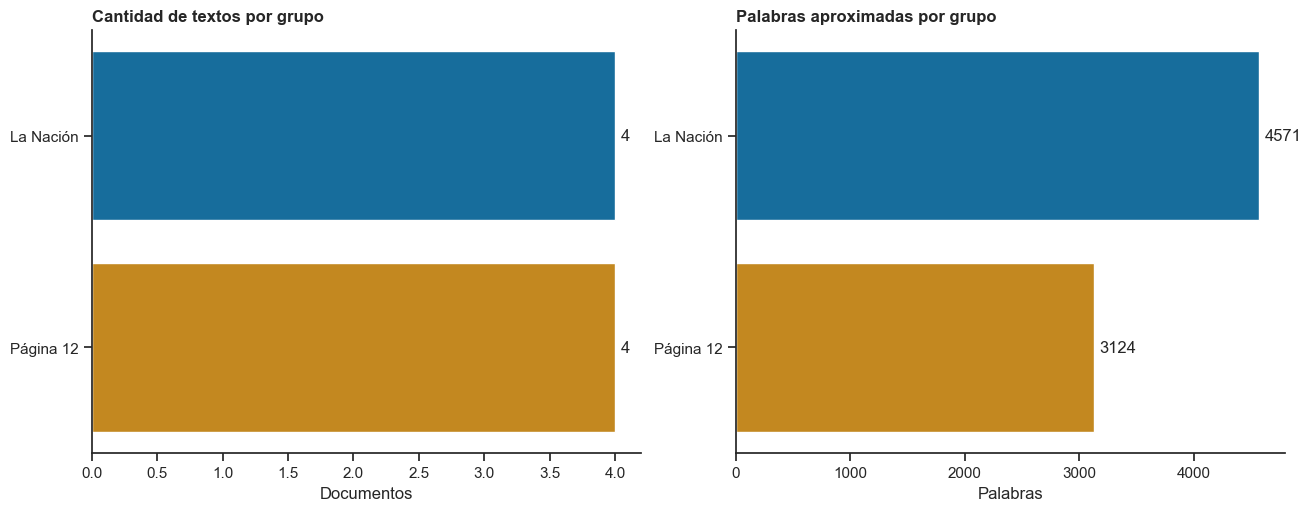

In [13]:
# Gráficos de comparación: cantidad de textos y palabras por grupo
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# Panel izquierdo: cantidad de documentos
sns.barplot(
    data=resumen_por_grupo,
    x="documentos",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    palette="colorblind",
    legend=False,
    ax=axes[0],
)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f", padding=4)
axes[0].set_title("Cantidad de textos por grupo", loc="left", fontweight="bold")
axes[0].set_xlabel("Documentos")
axes[0].set_ylabel("")
sns.despine(ax=axes[0])

# Panel derecho: palabras totales
sns.barplot(
    data=resumen_por_grupo,
    x="palabras_totales",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    palette="colorblind",
    legend=False,
    ax=axes[1],
)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.0f", padding=4)
axes[1].set_title("Palabras aproximadas por grupo", loc="left", fontweight="bold")
axes[1].set_xlabel("Palabras")
axes[1].set_ylabel("")
sns.despine(ax=axes[1])

plt.show()


**Pausa de lectura**

Miren estas tablas y gráficos como una auditoría del recorte. Si un grupo tiene mucha más longitud o muchas más piezas que el otro, anótenlo ahora: ese desbalance condiciona lo que después van a interpretar.


El grupo *La Nación (4.511)* tiene mayor longitud que el grupo *Pagina 12 (3.124)*

Diferencia de **1.387** caracteres.

## 6. Procesamiento lingüístico con spaCy

Ahora vamos a construir una capa intermedia de observables: lemas, palabras de contenido y entidades nombradas. No alcanza para interpretar por sí sola, pero sí ordena mejor el corpus para mirar recurrencias y contrastes.


In [14]:
# Cargamos el modelo de spaCy
try:
    import spacy
    nlp = spacy.load(MODELO_SPACY)
    print(f"Modelo cargado correctamente: {MODELO_SPACY}")
except Exception as error:
    raise RuntimeError(
        "No se pudo cargar spaCy. Instalá el modelo con "
        "`python -m spacy download es_core_news_sm` y volvé a correr el cuaderno."
    ) from error


Modelo cargado correctamente: es_core_news_sm


**NOTA**: Solo correr el siguiente codigo **una sola vez** porque se repite por salida la columna *"texto-contenido"*, de acuerdo a cuantas veces se haya ejecutado el código. 

In [15]:
def normalizar_lemma(token):
    """Obtiene el lema limpio de un token spaCy.
    Si el lema es vacío o el pronombre genérico, usa la forma original."""
    lema = token.lemma_.strip().lower()
    if not lema or lema == "-pron-":
        lema = token.text.lower()
    return lema


# --- Procesamos cada texto con spaCy ---
registros_linguisticos = []
for doc in nlp.pipe(df[COLUMNA_TEXTO].tolist(), batch_size=8):
    lemas = []
    contenido = []
    entidades = []

    for token in doc:
        if token.is_space:
            continue
        lema = normalizar_lemma(token)
        lemas.append(lema)
        # Solo palabras alfabéticas que no sean stopwords
        if token.is_alpha and not token.is_stop:
            contenido.append(lema)

    # Extraemos entidades nombradas (personas, organizaciones, lugares)
    for entidad in doc.ents:
        entidades.append({"texto": entidad.text, "etiqueta": entidad.label_})

    registros_linguisticos.append({
        "texto_lemas": " ".join(lemas),
        "texto_contenido": " ".join(contenido),
        "entidades": entidades,
    })

# Unimos los resultados al DataFrame principal
df_linguistico = pd.DataFrame(registros_linguisticos)
df = pd.concat([df.reset_index(drop=True), df_linguistico], axis=1)

display(df[["titulo", COLUMNA_GRUPO, "texto_contenido"]].head(8))


,titulo,grupo_comparacion,texto_contenido
0,La persecución judicial contra Cristina Kirchner Las escandalosas irregularidade,Página 12,persecución judicial cristina kirchner escandaloso irregularidad causa cuadernos raúl kollmann marzo causa cuadernos decir pagar cristin...
1,La expresidente rechazó las acusaciones en el juicio por las fotocopias de los c,Página 12,expresidente rechazar acusación juicio fotocopia cuaderno cristina kirchner denunciar chantaje extorsión causa mafioso feroz denuncia ju...
2,"Otra declaración que tampoco hizo ninguna referencia a CFK Cuadernos, el primer",Página 12,declaración referencia cfk cuadernos arrepentido cambiar representante española isolux desmentir escrito cuaderno aporte campaña elector...
3,"Otra declaración que tampoco hizo ninguna referencia a CFK Cuadernos, un arrepen",Página 12,declaración referencia cfk cuadernos arrepentido desmentir centeno representante española isolux desmentir escrito cuaderno aporte campa...
4,La defensa de Cristina Kirchner apuntó contra el presidente Milei por haber dich,La Nación,defensa cristina kirchner apuntar presidente milei seguir preso caso cuadernos beraldi abogado expresidenta referir pasaje presidente cr...
5,Cuadernos de las coimas: Cristina Kirchner denunció “prácticas mafiosas” y atacó,La Nación,cuadernos coima cristina kirchner denunciar práctica mafioso atacar fiscal juez declaración presencial expresidenta calificar caso dispa...
6,Los Cuadernos de las coimas: el chofer Centeno se negó a declarar y Uberti afirm,La Nación,cuadernos coima chofer centeno negar declarar uberti arrepentir traidor autor escrito disparar investigación caso anotación brindar deta...
7,Cuadernos de las Coimas: solo un arrepentido rompió el silencio en el juicio,La Nación,cuadernos coimas arrepentido romper silencio juicio rechazo imputado colaborador contestar pregunta reflotar planteo cristina kirchner e...


## 7. Observables iniciales: términos, entidades y bigramas

Acá empieza la lectura distante. La pregunta no es todavía "qué significa el corpus", sino "qué regularidades o contrastes aparecen cuando cambiamos de escala".


In [16]:
def obtener_top_terminos_por_grupo(dataframe, top_n=10):
    """Cuenta los términos de contenido en cada grupo
    y devuelve los top_n más frecuentes por grupo."""
    registros = []
    for grupo, subconjunto in dataframe.groupby(COLUMNA_GRUPO):
        contador = Counter(" ".join(subconjunto["texto_contenido"]).split()) # Contamos términos en el contenido de cada grupo
        for termino, frecuencia in contador.most_common(top_n): # Obtenemos los términos más comunes y su frecuencia
            registros.append({                                  # .most_common devuelve una lista de tuplas (término, frecuencia)
                "grupo": grupo,
                "término": termino,
                "frecuencia": frecuencia,
            })
    return pd.DataFrame(registros)


top_terminos = obtener_top_terminos_por_grupo(df, top_n=TOP_N)
display(top_terminos)


,grupo,término,frecuencia
0,La Nación,tribunal,32
1,La Nación,kirchner,30
2,La Nación,cristina,29
3,La Nación,causa,29
4,La Nación,pregunta,26
5,La Nación,cuadernos,23
6,La Nación,expresidenta,22
7,La Nación,empresario,19
8,La Nación,caso,18
9,La Nación,arrepentido,18


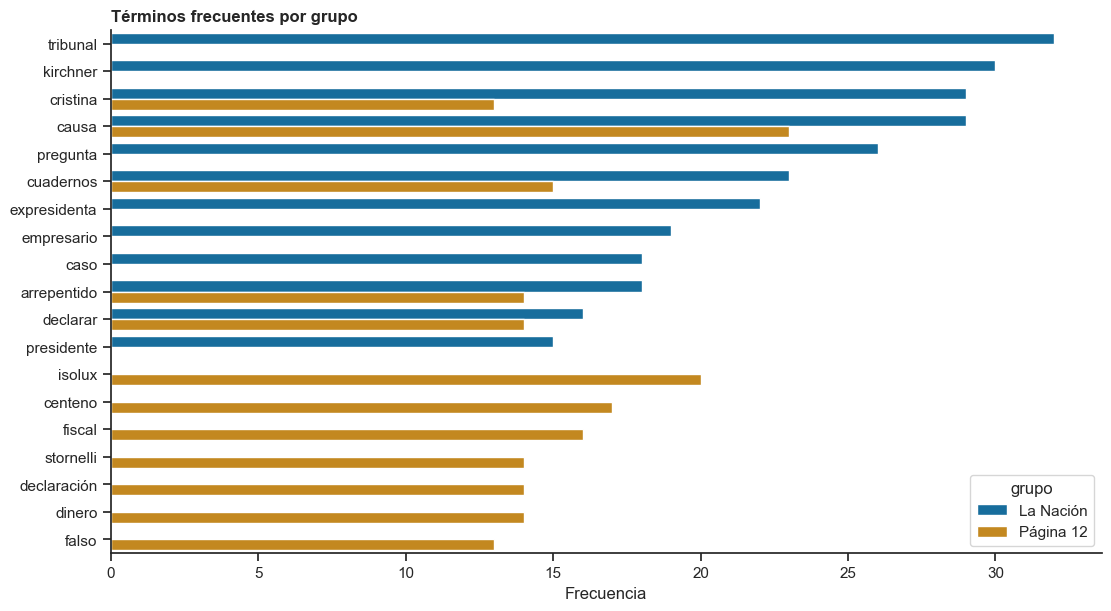

In [17]:
# Gráfico comparativo: términos frecuentes por grupo
fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
sns.barplot(
    data=top_terminos,
    x="frecuencia",
    y="término",
    hue="grupo",
    ax=ax,
)
ax.set_title("Términos frecuentes por grupo", loc="left", fontweight="bold")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("")
sns.despine(ax=ax)
plt.show()


In [18]:
# --- Entidades nombradas por grupo ---
# Desagregamos las entidades documento por documento
registros_entidades = []
for fila in df.itertuples(index=False): 
    for entidad in fila.entidades:
        registros_entidades.append({
            "grupo": getattr(fila, COLUMNA_GRUPO), # Obtenemos el grupo del documento actual
            "texto_entidad": entidad["texto"],     # getattr se usa para acceder a la columna de grupo
            "etiqueta": entidad["etiqueta"],
        })

df_entidades = pd.DataFrame(registros_entidades)

if not df_entidades.empty:
    # Agrupamos por grupo + texto + etiqueta, contamos y ordenamos
    top_entidades = (
        df_entidades.groupby(["grupo", "texto_entidad", "etiqueta"])
        .size() # Contamos cuántas veces aparece cada entidad en cada grupo
        .reset_index(name="frecuencia") # Convertimos el resultado a un DataFrame con una columna de frecuencia
        .sort_values(["grupo", "frecuencia"], ascending=[True, False]) # Ordenamos por grupo y frecuencia descendente
    )
    display(top_entidades.head(TOP_N * 2))
else:
    top_entidades = pd.DataFrame(columns=["grupo", "texto_entidad", "etiqueta", "frecuencia"])
    print("No se detectaron entidades suficientes para armar una tabla de trabajo.")


,grupo,texto_entidad,etiqueta,frecuencia
38,La Nación,Cristina Kirchner,PER,22
166,La Nación,Tribunal,LOC,9
109,La Nación,Malvinas,LOC,8
23,La Nación,Centeno,PER,7
42,La Nación,Cuadernos,ORG,6
185,La Nación,Wagner,PER,6
130,La Nación,Néstor Kirchner,PER,5
160,La Nación,Stornelli,PER,5
181,La Nación,Vialidad,LOC,5
16,La Nación,Beraldi,PER,4


In [19]:
# --- Bigramas por grupo ---
# Vectorizamos con bigramas (ngram_range=(2,2)) sobre el texto de contenido
vectorizador_bigramas = CountVectorizer(lowercase=False, ngram_range=(2, 2), min_df=1) 
matriz_bigramas = vectorizador_bigramas.fit_transform(df["texto_contenido"]) # Creamos una matriz de términos (bigramas) por documento

# Convertimos a DataFrame con títulos como índice
tabla_bigramas = pd.DataFrame(
    matriz_bigramas.toarray(),
    index=df["titulo"],
    columns=vectorizador_bigramas.get_feature_names_out(),
)

# Sumamos bigramas dentro de cada grupo
bigramas_por_grupo = (
    tabla_bigramas.assign(grupo=df[COLUMNA_GRUPO].values)
    .groupby("grupo")
    .sum()
    .T
)

# Extraemos los top_n bigramas de cada grupo
registros_bigramas = []
for grupo in bigramas_por_grupo.columns:
    top = bigramas_por_grupo[grupo].sort_values(ascending=False).head(TOP_N)
    for bigrama, frecuencia in top.items():
        registros_bigramas.append({
            "grupo": grupo,
            "bigrama": bigrama,
            "frecuencia": int(frecuencia),
        })

top_bigramas = pd.DataFrame(registros_bigramas)
display(top_bigramas)


,grupo,bigrama,frecuencia
0,La Nación,cristina kirchner,24
1,La Nación,contestar pregunta,11
2,La Nación,méndez signori,9
3,La Nación,red social,8
4,La Nación,cuadernos coimas,6
5,La Nación,néstor kirchner,5
6,La Nación,julio vido,5
7,La Nación,causa cuadernos,5
8,La Nación,tribunal oral,5
9,La Nación,fabiana león,5


**Pausa de lectura**

Hasta acá no alcanza con decir "este grupo usa más tal palabra". Anoten qué términos, entidades o asociaciones parecen organizar mejor cada serie y cuáles todavía necesitan volver al texto para no sobredimensionar la frecuencia.


ORGANIZAN MEJOR LA SERIE: \
**TERMINOS**: Causa, cuadernos, cristina \
**ENTIDADES**: Cristina Kirchner (Dato curioso no hay entidades que pertenezcan al grupo de Pagina 12 en el TOP) \
**ASOCIACIONES**: Cristina Kirchner, causa cuaderno, cuadernos coimas

VUELTA AL TEXTO: \
**TERMINOS**: Ninguno sobredimensiona\
**ENTIDADES**: Aparecen estas entidades que no deberían estar y es porque el scraping de La Nación tomó noticias paralelas que mencionan las siguientes entidades: Donald Trump, Además, Trump, Malvinas, Luis Caputo \
**ASOCIACIONES**: También deberíamos sacar estas Asociaciones. Dólar blue por el mismo motivo que lo anteriormente comentado y Raúl Kollmann porque es el autor de las notas de Página 12 y kollmann marzo porque es el autor más el mes de publicación: Dólar blue, Raúl Kollmann, kollmann marzo

## 8. Bag of Words y TF-IDF

En esta sección el contraste ya no es solo documento por documento. Vamos a reunir los textos de cada grupo para ver qué vocabulario aparece con fuerza y qué términos resultan más distintivos en cada serie.


In [20]:
# Concatenamos todos los textos de contenido de cada grupo en un solo string
corpus_por_grupo = (
    df.groupby(COLUMNA_GRUPO, as_index=False)
    .agg(texto_modelo=("texto_contenido", " ".join))
    .rename(columns={COLUMNA_GRUPO: "grupo"})
)

display(corpus_por_grupo)


,grupo,texto_modelo
0,La Nación,defensa cristina kirchner apuntar presidente milei seguir preso caso cuadernos beraldi abogado expresidenta referir pasaje presidente cr...
1,Página 12,persecución judicial cristina kirchner escandaloso irregularidad causa cuadernos raúl kollmann marzo causa cuadernos decir pagar cristin...


In [21]:
# --- Funciones auxiliares para BoW y TF-IDF ---

def matriz_a_dataframe(matriz, nombres_columnas, nombres_filas):
    """Convierte una matriz sparse en un DataFrame legible."""
    return pd.DataFrame(matriz.toarray(), columns=nombres_columnas, index=nombres_filas) # matriz.toarray() convierte la matriz sparse a un array denso, luego lo pasamos a DataFrame con las columnas y filas adecuadas


def extraer_top_por_grupo(tabla_matriz, top_n=10, nombre_valor="valor"):
    """Para cada grupo (fila), extrae los top_n términos con mayor valor."""
    registros = []
    for grupo, serie in tabla_matriz.iterrows():
        # Filtramos valores > 0, ordenamos de mayor a menor
        top = serie[serie > 0].sort_values(ascending=False).head(top_n)
        for termino, valor in top.items():
            registros.append({
                "grupo": grupo,
                "término": termino,
                nombre_valor: round(float(valor), 4),
            })
    return pd.DataFrame(registros)


# --- Bag of Words (CountVectorizer) ---
# max_df=0.95 descarta términos que aparecen en >95% de los documentos
vectorizador_bow = CountVectorizer(lowercase=False, min_df=MIN_DF, max_df=MAX_DF)
matriz_bow = vectorizador_bow.fit_transform(corpus_por_grupo["texto_modelo"])
tabla_bow = matriz_a_dataframe(matriz_bow, vectorizador_bow.get_feature_names_out(), corpus_por_grupo["grupo"]) #.get_feature_names_out() devuelve una lista con los nombres de las columnas (términos) que corresponden a cada posición en la matriz
top_bow = extraer_top_por_grupo(tabla_bow, top_n=TOP_N, nombre_valor="frecuencia")

# --- TF-IDF (TfidfVectorizer) ---
vectorizador_tfidf = TfidfVectorizer(lowercase=False, min_df=MIN_DF, max_df=MAX_DF)
matriz_tfidf = vectorizador_tfidf.fit_transform(corpus_por_grupo["texto_modelo"])
tabla_tfidf = matriz_a_dataframe(matriz_tfidf, vectorizador_tfidf.get_feature_names_out(), corpus_por_grupo["grupo"])
top_tfidf = extraer_top_por_grupo(tabla_tfidf, top_n=TOP_N, nombre_valor="tfidf")

# --- Mostramos ambas tablas ---
print("Top de términos según Bag of Words")
display(top_bow)
print("Top de términos según TF-IDF")
display(top_tfidf)


Top de términos según Bag of Words


,grupo,término,frecuencia
0,La Nación,proceso,12.0
1,La Nación,trump,8.0
2,La Nación,seguir,8.0
3,La Nación,social,8.0
4,La Nación,red,8.0
5,La Nación,malvinas,8.0
6,La Nación,coimas,7.0
7,La Nación,wagner,7.0
8,La Nación,beraldi,7.0
9,La Nación,recaudación,6.0


Top de términos según TF-IDF


,grupo,término,tfidf
0,La Nación,proceso,0.2292
1,La Nación,trump,0.1528
2,La Nación,seguir,0.1528
3,La Nación,social,0.1528
4,La Nación,red,0.1528
5,La Nación,malvinas,0.1528
6,La Nación,coimas,0.1337
7,La Nación,wagner,0.1337
8,La Nación,beraldi,0.1337
9,La Nación,recaudación,0.1146


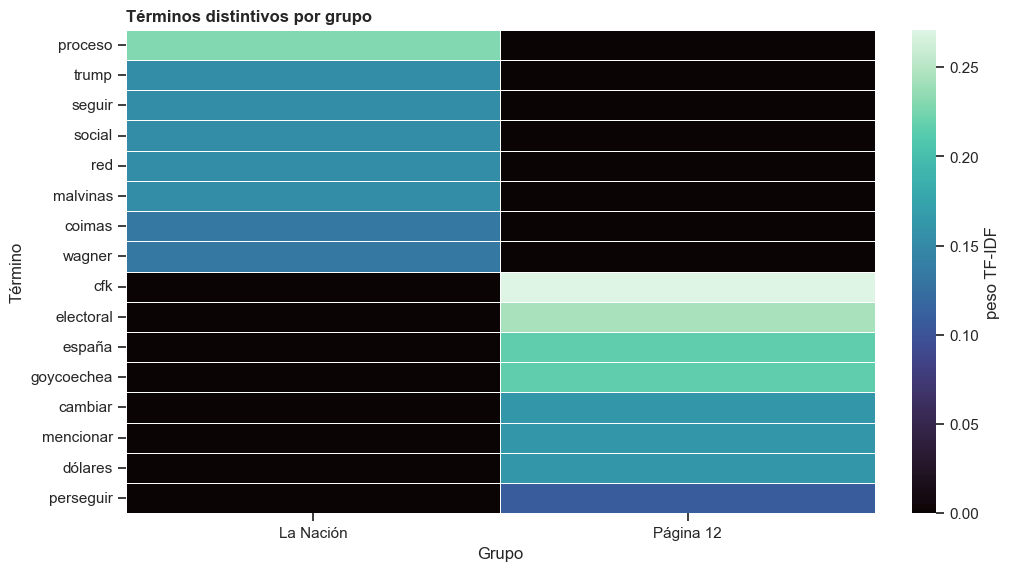

In [22]:
# Mapa de calor: términos distintivos por grupo
# Seleccionamos los top-8 términos TF-IDF de cada grupo (sin repetir)
terminos_heatmap = list(dict.fromkeys(
    top_tfidf.groupby("grupo").head(8)["término"].tolist()
))
matriz_heatmap = tabla_tfidf[terminos_heatmap].T

fig, ax = plt.subplots(
    figsize=(10, max(4, len(terminos_heatmap) * 0.35)),
    constrained_layout=True,
)
sns.heatmap(
    matriz_heatmap,
    cmap="mako",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "peso TF-IDF"},
    ax=ax,
)
ax.set_title("Términos distintivos por grupo", loc="left", fontweight="bold")
ax.set_xlabel("Grupo")
ax.set_ylabel("Término")
plt.show()


**Pausa de lectura**

Acá conviene comparar dos cosas:

- qué términos son frecuentes en ambos grupos;
- qué términos no necesariamente son los más frecuentes, pero sí los más distintivos según `TF-IDF`.

No confundan volumen con especificidad. Esa diferencia es central en este trabajo.


**Terminos frecuentes en ambos grupos**: *Grupo La Nación*: proceso, seguir, trump \
  --------------------------------------------*Grupo Página 12*: cfk, electoral, españa \
**Terminos distintivos**: hay una correlación entre la frecuencia y el peso según TF-IFD para establecer los terminos más distintivos

## 9. Del patrón al fragmento

La lectura distante orienta. La lectura cercana confirma, corrige o complejiza. Ahora vamos a elegir algunos términos distintivos y a volver a los textos para ver cómo aparecen en contexto.


In [23]:
# Tomamos los 2 términos más distintivos de cada grupo
terminos_para_volver = top_tfidf.groupby("grupo").head(2).reset_index(drop=True)
display(terminos_para_volver)


,grupo,término,tfidf
0,La Nación,proceso,0.2292
1,La Nación,trump,0.1528
2,Página 12,cfk,0.2710
3,Página 12,electoral,0.2439


In [24]:
def extraer_fragmentos(dataframe, grupo, termino, columna_texto="texto", ventana=140, max_fragmentos=3):
    """Busca un término en los textos originales de un grupo y devuelve
    hasta max_fragmentos centrados en la primera aparición de cada texto."""
    patron = re.compile(rf"\b{re.escape(termino)}\b", flags=re.IGNORECASE)
    registros = []
    subconjunto = dataframe[dataframe[COLUMNA_GRUPO] == grupo]

    for fila in subconjunto.itertuples(index=False):
        texto = getattr(fila, columna_texto)
        coincidencia = patron.search(texto)
        if not coincidencia:
            continue

        # Recortamos una ventana alrededor de la primera aparición
        inicio = max(0, coincidencia.start() - ventana)
        fin = min(len(texto), coincidencia.end() + ventana)
        fragmento = texto[inicio:fin].strip()

        # Agregamos "..." si el fragmento no empieza/termina con el texto completo
        if inicio > 0:
            fragmento = "..." + fragmento
        if fin < len(texto):
            fragmento = fragmento + "..."

        registros.append({
            "grupo": grupo,
            "término": termino,
            "título": fila.titulo,
            "fragmento": fragmento,
        })
        if len(registros) >= max_fragmentos:
            break
    return registros


# --- Buscamos los fragmentos para cada término distintivo ---
registros_fragmentos = []
for fila in terminos_para_volver.itertuples(index=False):
    registros_fragmentos.extend(
        extraer_fragmentos(
            df,
            grupo=fila.grupo,
            termino=fila.término,
            columna_texto=COLUMNA_TEXTO,
            ventana=VENTANA_FRAGMENTO,
            max_fragmentos=3,
        )
    )

fragmentos = pd.DataFrame(registros_fragmentos)
display(fragmentos)


,grupo,término,título,fragmento
0,La Nación,proceso,La defensa de Cristina Kirchner apuntó contra el presidente Milei por haber dich,"...los tres jueces que hoy integran la Corte Suprema de la Nación, ha vertido expresiones que afectan de manera directa el desarrollo de..."
1,La Nación,proceso,Cuadernos de las coimas: Cristina Kirchner denunció “prácticas mafiosas” y atacó,"...el juicio de los cuadernos de las coimas en los tribunales de Comodoro Py 2002. En su alocución, de casi una hora, intentó desacredit..."
2,La Nación,proceso,Los Cuadernos de las coimas: el chofer Centeno se negó a declarar y Uberti afirm,"...o contestó preguntas del Tribunal Oral Federal n°7. La expresidenta, que ocupa el centro de la escena en el juicio, intentó desacredi..."
3,La Nación,trump,La defensa de Cristina Kirchner apuntó contra el presidente Milei por haber dich,"...festín para los empresarios acusados de corrupción\n- 1\nCruces por Malvinas en las redes sociales entre un periodista británico, el ..."
4,La Nación,trump,Cuadernos de las coimas: Cristina Kirchner denunció “prácticas mafiosas” y atacó,"...del país, se compone de 8 causas distintas, 6 de las cuales están siendo ahora juzgadas por el TOF 7.\n- 1\nMalvinas y la apuesta por..."
5,La Nación,trump,Los Cuadernos de las coimas: el chofer Centeno se negó a declarar y Uberti afirm,"...festín para los empresarios acusados de corrupción\n- 1\nCruces por Malvinas en las redes sociales entre un periodista británico, el ..."
6,Página 12,cfk,La persecución judicial contra Cristina Kirchner Las escandalosas irregularidade,"...ina Kirchner una coima, cuándo se la pagaron, cómo la recibió. Ni siquiera los (falsos) arrepentidos la mencionaron. Como ya es habit..."
7,Página 12,cfk,La expresidente rechazó las acusaciones en el juicio por las fotocopias de los c,"...cios en que esas preguntas se pasan por alto. Pero el clima ya parecía espeso, entre otras cosas, por la decisión de los magistrados ..."
8,Página 12,cfk,"Otra declaración que tampoco hizo ninguna referencia a CFK Cuadernos, el primer","Otra declaración que tampoco hizo ninguna referencia a CFK Cuadernos, el primer arrepentido que cambió mucho El representante de la espa..."
9,Página 12,electoral,"Otra declaración que tampoco hizo ninguna referencia a CFK Cuadernos, el primer","...ambió mucho El representante de la española Isolux desmintió buena parte de lo escrito en los cuadernos, dijo que fueron aportes de c..."


## 10. Escritura interpretativa

Agreguen una o más celdas Markdown nuevas y respondan estas preguntas:

1. **Recorte y comparación**
   - ¿Qué comparan exactamente?
   - ¿Qué vuelve válidos esos dos grupos como contraste?

2. **Lectura distante**
   - ¿Qué términos, entidades o asociaciones lexicales organizan cada grupo?
   - ¿Qué diferencias aparecen con más claridad cuando miran `TF-IDF` y no solo frecuencias?

3. **Lectura cercana**
   - ¿Cómo aparece en contexto al menos uno de los términos distintivos de cada grupo?
   - ¿Qué cambia cuando vuelven al fragmento?

4. **Visualización y método**
   - ¿Qué gráfico ayudó realmente a comprender mejor el contraste?
   - ¿Qué límites tiene este enfoque para leer discurso?
   - ¿Qué no se puede afirmar solo con estas representaciones sparse?


1. **Recorte y comparación** \
   Lo que buscamos comparar es la producción informativa sobre un mismo tema presentado por dos medios gráficos de posturas distintas y contrapuestas.\
   La validez de los grupos radica en su larga trayectoria y presencia en la comunicación de sucesos y eventos importantes y trascendentales del país. Marcan opinión de acuerdo a una línea editorial notoria, que permite compararlos. 

2. **Lectura distante** 

   Grupo La Nación: 
    - **Términos**: *cristina*, *cuadernos*, *caso* , *tribunal*  
    - **Entidades**: *Cristina Kirchner* , *tribunal*, *cuadernos*
    - **Asociaciones**: *cristina kirchner*, *contestar pregunta* ,	*méndez signori*,	*cuadernos coimas*

   Grupo Página 12:
    - **Terminos**: *cristina*,*cuadernos*,*caso*,*centeno*
    - **Entidades**: no hay entidades pertenecientes a este grupo en el TOP
    - **Asociaciones**: *causa cuadernos*, *mauricio macri*, *aporte electoral*, *cristina kirchner*

   Las diferencias que encontramos al mirar los resultados de aplicar TF-IDF: 

   Grupo La Nación:
    - **Terminos**: *proceso*, *seguir*, *trump*

   Grupo Página 12:
    - **Terminos**: *cfk*, *electoral*, *españa*

   Solo el termino *cfk* referente a *Cristina Kirchner* es el que mantiene correlación con frecuencia y peso.

3. **Lectura cercana**

   Grupo La Nación:
   Elegimos el término "trump" porque el contexto muestra que no debería estar incluido en el análisis ya que pertenece a un texto que era secundario a la noticia.

   Grupo Página 12:
   Elegimos el término "españa" porque en contexto resulta poco significativo. Aparece porque figura en 2 noticias que resultaron ser prácticamente idénticas, con diferentes fechas y títulos y se centran en una declaración de un involucrado que menciona haber estado en España. No es relevante para el análisis general o por lo menos no debería tener el peso que se le adjudica.

4. Visualización y método

   El gráfico que ayuda a comprender mejor el contraste es el heatmpap, en el que se aprecia la radical diferencia de posturas, incluso a pesar de los defectos del análisis. 
   En cuanto a los límites, como fuimos exponiendo a lo largo del notebook, se registran los siguientes problemas:
      Debimos hacer una subida manual de los contenidos de los artículos de Página 12 por las dificultades para obtener las notas por scraping.
      No extrajo de manera correcta las fechas de publicación y nombres de los autores en el caso de La Nación, que se hizo por scraping.
      Al autor de las notas de Página 12 lo considera parte del cuerpo de la noticia y no lo separa como autor.
      En el caso de La Nación se incluyeron textos de notas paralelas y secundarias y eso impactó en el análisis ya que incluyó el término "trump" como significativo, entre otros.
      No identificó Entidades en los artículos de Página 12.
   No podemos afirmar solamente con este análisis que los resultados y por ende las conclusiones que se pueden obtener a partir de esta información sean concluyentes.



In [31]:
# --- Exportación opcional de tablas auxiliares ---
EXPORTAR_RESULTADOS = False
CARPETA_SALIDA = Path("salidas_tpi2")

if EXPORTAR_RESULTADOS:
    CARPETA_SALIDA.mkdir(exist_ok=True)
    resumen_corpus.to_csv(CARPETA_SALIDA / "resumen_corpus.csv", index=False)
    resumen_por_grupo.to_csv(CARPETA_SALIDA / "resumen_por_grupo.csv", index=False)
    top_terminos.to_csv(CARPETA_SALIDA / "top_terminos_por_grupo.csv", index=False)
    top_entidades.to_csv(CARPETA_SALIDA / "top_entidades.csv", index=False)
    top_bigramas.to_csv(CARPETA_SALIDA / "top_bigramas.csv", index=False)
    top_bow.to_csv(CARPETA_SALIDA / "top_bow.csv", index=False)
    top_tfidf.to_csv(CARPETA_SALIDA / "top_tfidf.csv", index=False)
    fragmentos.to_csv(CARPETA_SALIDA / "fragmentos.csv", index=False)
    print(f"Se exportaron archivos en {CARPETA_SALIDA.resolve()}")
else:
    print("Exportación desactivada. Si quieren guardar tablas auxiliares, cambien EXPORTAR_RESULTADOS a True.")


Exportación desactivada. Si quieren guardar tablas auxiliares, cambien EXPORTAR_RESULTADOS a True.


## 11. Checklist final de entrega

Antes de entregar, revisen esto:

- ¿El corpus tiene entre 6 y 10 textos y exactamente dos grupos comparables?
- ¿La columna `grupo_comparacion` está completa y bien usada?
- ¿Usaron `spaCy`, `Bag of Words`, `TF-IDF` y al menos una lectura de bigramas?
- ¿Incluyeron al menos dos visualizaciones analíticas legibles?
- ¿Volvieron al menos a tres fragmentos concretos?
- ¿Hay una interpretación final y una sección explícita de límites?
- ¿El notebook corre de principio a fin sin depender de ediciones manuales intermedias?

Si pueden responder que sí a todo, la entrega ya tiene la estructura mínima esperada para el TPI 2.
